# K-MEANS KUMELEME ALGORITMASI
## Seeds (Bugday Tohumu) Veri Seti Uzerinde Uygulama

Bu calismada K-Means kumeleme algoritmasi, Seeds veri seti uzerinde uygulanacaktir.

---
## 1. GEREKLI KUTUPHANELERIN YUKLENMESI

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import adjusted_rand_score

plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
print('Kutuphaneler basariyla yuklendi.')

Kutuphaneler basariyla yuklendi.


---
## 2. VERI SETININ YUKLENMESI VE KESFI

In [2]:
columns = ['Area', 'Perimeter', 'Compactness', 'Kernel_Length', 'Kernel_Width',
           'Asymmetry_Coeff', 'Kernel_Groove_Length', 'Class']
df = pd.read_csv('data/seeds_dataset.txt', sep=r'\s+', header=None, names=columns)
print(f'Veri seti boyutu: {df.shape}')
print(f'Sutun sayisi: {len(df.columns)}')
print(f'Satir sayisi: {len(df)}')

Veri seti boyutu: (210, 8)
Sutun sayisi: 8
Satir sayisi: 210


In [3]:
df.head()

,Area,Perimeter,Compactness,Kernel_Length,Kernel_Width,Asymmetry_Coeff,Kernel_Groove_Length,Class
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Area                  210 non-null    float64
 1   Perimeter             210 non-null    float64
 2   Compactness           210 non-null    float64
 3   Kernel_Length         210 non-null    float64
 4   Kernel_Width          210 non-null    float64
 5   Asymmetry_Coeff       210 non-null    float64
 6   Kernel_Groove_Length  210 non-null    float64
 7   Class                 210 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 13.3 KB


In [5]:
df.describe()

,Area,Perimeter,Compactness,Kernel_Length,Kernel_Width,Asymmetry_Coeff,Kernel_Groove_Length,Class
count,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000
mean,14.847524,14.559286,0.870999,5.628533,3.258605,3.700201,5.408071,2.000000
std,2.909699,1.305959,0.023629,0.443063,0.377714,1.503557,0.491480,0.818448
min,10.590000,12.410000,0.808100,4.899000,2.630000,0.765100,4.519000,1.000000
25%,12.270000,13.450000,0.856900,5.262250,2.944000,2.561500,5.045000,1.000000
50%,14.355000,14.320000,0.873450,5.523500,3.237000,3.599000,5.223000,2.000000
75%,17.305000,15.715000,0.887775,5.979750,3.561750,4.768750,5.877000,3.000000
max,21.180000,17.250000,0.918300,6.675000,4.033000,8.456000,6.550000,3.000000


In [6]:
print('Eksik deger sayilari:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f'\nToplam eksik deger: {df.isnull().sum().sum()}')

Eksik deger sayilari:
Series([], dtype: int64)

Toplam eksik deger: 0


---
## 3. VERI ON ISLEME

In [7]:
X = df.drop('Class', axis=1)
y_true = df['Class']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print('Olceklendirilmis veri (ilk 5 satir):')
X_scaled.head()

Olceklendirilmis veri (ilk 5 satir):


,Area,Perimeter,Compactness,Kernel_Length,Kernel_Width,Asymmetry_Coeff,Kernel_Groove_Length
0,0.142098,0.215462,0.000061,0.304218,0.141702,-0.986152,-0.383577
1,0.011188,0.008224,0.428515,-0.168625,0.197432,-1.788166,-0.922013
2,-0.192067,-0.360201,1.442383,-0.763637,0.208048,-0.667479,-1.189192
3,-0.347091,-0.475333,1.039381,-0.688978,0.319508,-0.960818,-1.229983
4,0.445257,0.330595,1.374509,0.066666,0.805159,-1.563495,-0.475356


---
## 4. K-MEANS KUMELEME ALGORITMASI

Algoritma açıklaması ve teorik detaylar için bkz. **`KONU_ANLATIMI.md`**

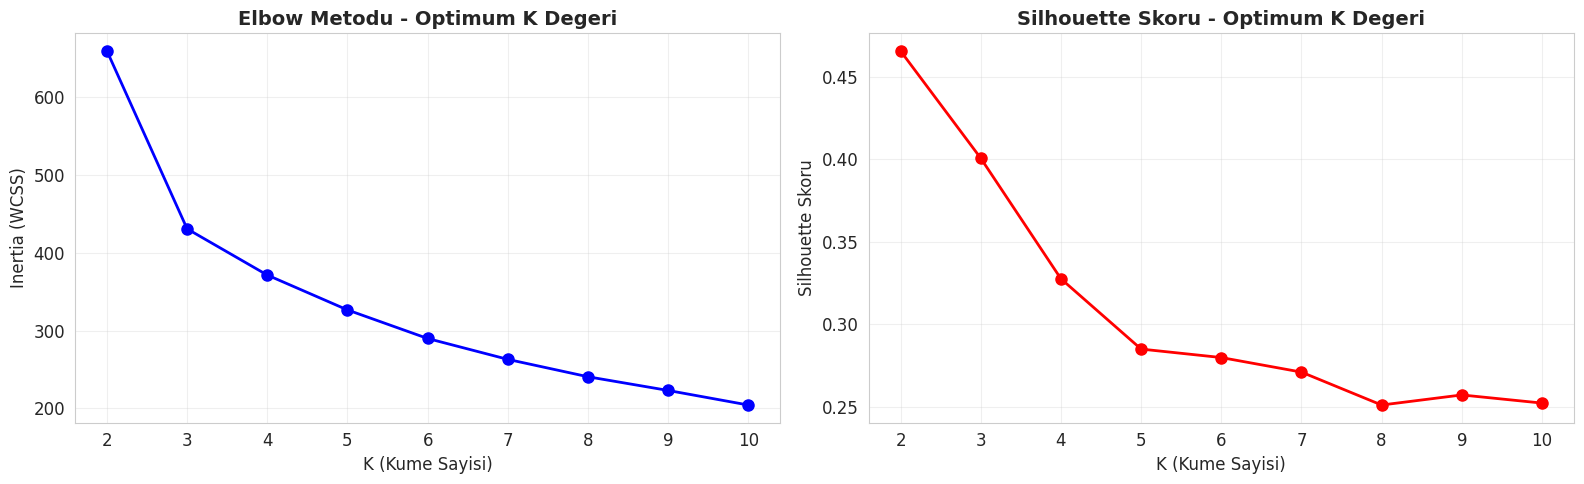

En iyi silhouette skoru: 0.4658
Optimum K degeri: 2


In [8]:
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Metodu - Optimum K Degeri', fontsize=14, fontweight='bold')
axes[0].set_xlabel('K (Kume Sayisi)', fontsize=12)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Skoru - Optimum K Degeri', fontsize=14, fontweight='bold')
axes[1].set_xlabel('K (Kume Sayisi)', fontsize=12)
axes[1].set_ylabel('Silhouette Skoru', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

optimal_k = K_range[np.argmax(silhouette_scores)]
print(f'En iyi silhouette skoru: {max(silhouette_scores):.4f}')
print(f'Optimum K degeri: {optimal_k}')

In [9]:
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

print('K-Means Kumeleme Sonuclari:')
print(f'Kume sayisi: {optimal_k}')
print(f'Silhouette Skoru: {silhouette_score(X_scaled, kmeans_labels):.4f}')
print(f'Davies-Bouldin Indeksi: {davies_bouldin_score(X_scaled, kmeans_labels):.4f}')
print(f'Calinski-Harabasz Skoru: {calinski_harabasz_score(X_scaled, kmeans_labels):.4f}')
print(f'\nKume dagilimi:')
print(pd.Series(kmeans_labels).value_counts().sort_index())

K-Means Kumeleme Sonuclari:
Kume sayisi: 3
Silhouette Skoru: 0.4007
Davies-Bouldin Indeksi: 0.9279
Calinski-Harabasz Skoru: 249.7842

Kume dagilimi:
0    72
1    67
2    71
Name: count, dtype: int64


In [10]:
df['KMeans_Cluster'] = kmeans_labels
cluster_summary = df.groupby('KMeans_Cluster').mean(numeric_only=True).round(2)
print('K-Means Kume Profilleri:')
cluster_summary

K-Means Kume Profilleri:


,Area,Perimeter,Compactness,Kernel_Length,Kernel_Width,Asymmetry_Coeff,Kernel_Groove_Length,Class
KMeans_Cluster,,,,,,,,
0,11.86,13.25,0.85,5.23,2.85,4.74,5.10,2.83
1,18.50,16.20,0.88,6.18,3.70,3.63,6.04,1.97
2,14.44,14.34,0.88,5.51,3.26,2.71,5.12,1.18


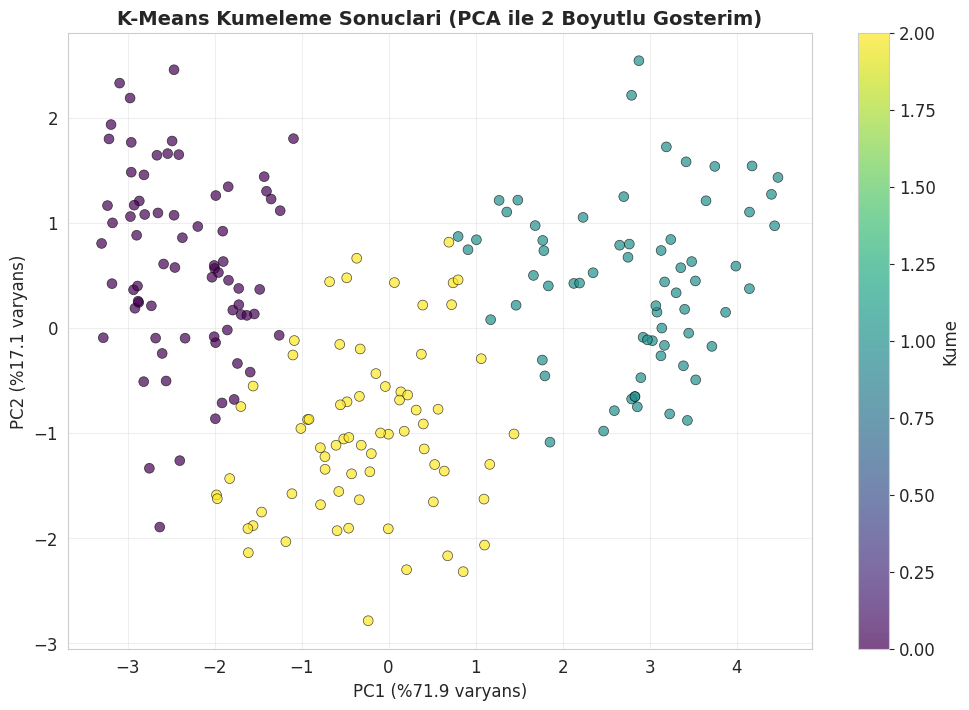

In [11]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis',
                      alpha=0.7, s=50, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Kume')
plt.title('K-Means Kumeleme Sonuclari (PCA ile 2 Boyutlu Gosterim)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0]*100:.1f} varyans)', fontsize=12)
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1]*100:.1f} varyans)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

---
## 5. GERCEK ETIKETLERLE KARSILASTIRMA

Seeds veri setinde her tohumun gercek cesidi (Class: 1, 2, 3) bilinmektedir.
K-Means'in bulmus oldugu kumeler, gercek siniflarla Adjusted Rand Index (ARI) kullanilarak karsilastirilabilir.

Adjusted Rand Index (K-Means vs Gercek Siniflar): 0.7733


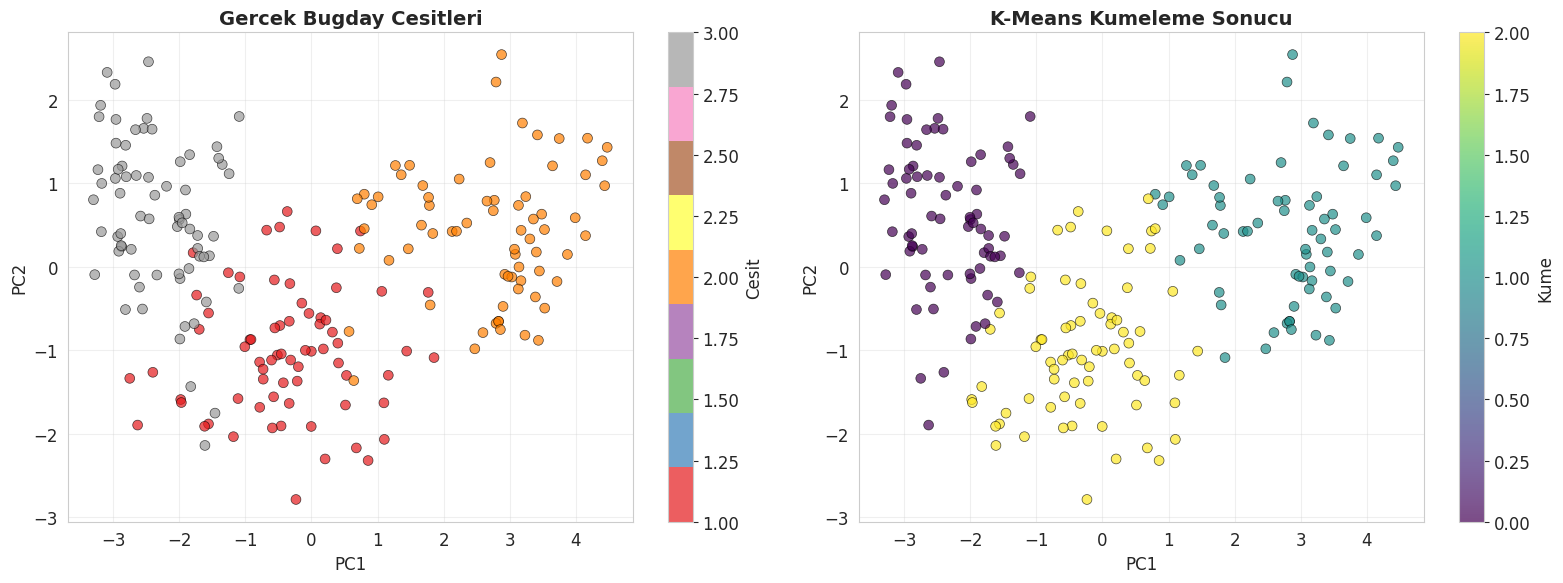

In [12]:
ari_score = adjusted_rand_score(y_true, kmeans_labels)
print(f'Adjusted Rand Index (K-Means vs Gercek Siniflar): {ari_score:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='Set1',
                            alpha=0.7, s=50, edgecolors='k', linewidth=0.5)
axes[0].set_title('Gercek Bugday Cesitleri', fontsize=14, fontweight='bold')
axes[0].set_xlabel('PC1', fontsize=12)
axes[0].set_ylabel('PC2', fontsize=12)
plt.colorbar(scatter1, ax=axes[0], label='Cesit')
axes[0].grid(True, alpha=0.3)

scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis',
                            alpha=0.7, s=50, edgecolors='k', linewidth=0.5)
axes[1].set_title('K-Means Kumeleme Sonucu', fontsize=14, fontweight='bold')
axes[1].set_xlabel('PC1', fontsize=12)
axes[1].set_ylabel('PC2', fontsize=12)
plt.colorbar(scatter2, ax=axes[1], label='Kume')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 6. SONUC VE DEGERLENDIRME

- Seeds veri seti uzerinde K-Means algoritmasi, optimum K=3 degeri ile uygulanmistir.
- Bu deger, veri setindeki gercek bugday cesidi sayisiyla (3 cesit) ortusmektedir.
- Silhouette, Davies-Bouldin ve Calinski-Harabasz skorlari kumeleme kalitesinin iyi oldugunu gostermektedir.
- Adjusted Rand Index skoru, K-Means'in bulmus oldugu kumelerin gercek siniflarla ne kadar ortustugunu ortaya koymaktadir.
- K-Means, basit ve hizli yapisi sayesinde bu tur dusuk boyutlu, iyi ayrisan veri setlerinde basarili sonuclar vermistir.